In [5]:
import pandas_datareader as pdr

In [2]:
!pip install yfinance

  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
  Using cached websockets-16.0-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
Using cached yfinance-1.2.0-py2.py3-none-any.whl (130 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
Using cached websockets-16.0-cp313-cp313-win_amd64.whl (178 kB)

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   -----------------------------

In [9]:
import yfinance as yf

df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')

data = df['Close'].values
data = data.reshape(-1, 1)

print(data[:5])
df.reset_index(inplace=True)

print(df.head())

[*********************100%***********************]  1 of 1 completed

[[24.21489334]
 [23.53272438]
 [23.53493881]
 [23.86495209]
 [24.78188896]]
Price        Date      Close       High        Low       Open     Volume
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL
0      2015-01-02  24.214893  24.682226  23.776353  24.671151  212818400
1      2015-01-05  23.532724  24.064287  23.346678  23.984553  257142000
2      2015-01-06  23.534939  23.794075  23.173918  23.596954  263188400
3      2015-01-07  23.864952  23.964619  23.632393  23.743135  160423600
4      2015-01-08  24.781889  24.839475  24.075353  24.192741  237458000


In [10]:
df.tail()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
2259,2023-12-22,191.609497,193.400885,190.985970,193.173239,37149600
2260,2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300
2261,2023-12-27,191.164078,191.510485,189.125261,190.510875,48087700
2262,2023-12-28,191.589630,192.658527,191.183842,192.143870,34049900
2263,2023-12-29,190.550461,192.401229,189.758683,191.906370,42672100


In [16]:
print("Start")
df1 = df['Close']
df1 = df1.values
df1 = df1.reshape(-1,1)
print("Shape is:", df1.shape)
print("End")

Start
Shape is: (2264, 1)
End


In [17]:
df1

array([[ 24.21489334],
       [ 23.53272438],
       [ 23.53493881],
       ...,
       [191.16407776],
       [191.58963013],
       [190.55046082]], shape=(2264, 1))

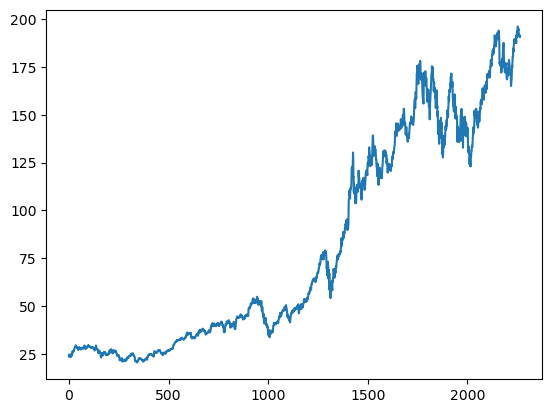

In [18]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [19]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [20]:
df1.shape

(2264, 1)

In [21]:
# splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [22]:

training_size,test_size

(1471, 793)

In [23]:
train_data

array([[0.02068559],
       [0.01679833],
       [0.01681095],
       ...,
       [0.48495438],
       [0.48445641],
       [0.49369538]], shape=(1471, 1))

In [24]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [25]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [26]:

print(X_train.shape), print(y_train.shape)

(1370, 100)
(1370,)


(None, None)

In [27]:

print(X_test.shape), print(ytest.shape)

(692, 100)
(692,)


(None, None)

In [28]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [31]:

### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [30]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using ca

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [34]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(60,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:

import tensorflow as tf

In [37]:

tf.__version__

'2.21.0'

In [38]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


In [39]:
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [40]:

### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

24.49065607174685

In [41]:

### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

40.69050038550954

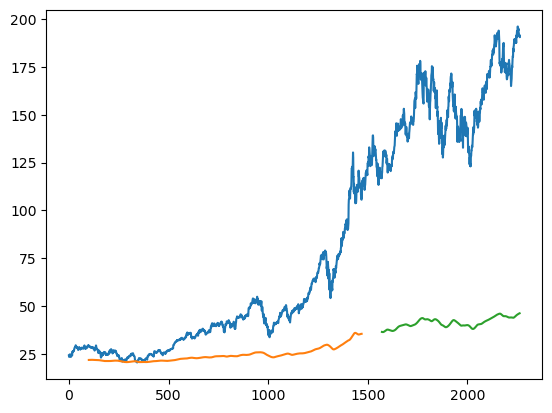

In [42]:
### Plotting 
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [43]:

len(test_data)


793

In [44]:

x_input=test_data[341:].reshape(1,-1)
x_input.shape

(1, 452)

In [45]:

temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [46]:

temp_input

[0.7485968069288219,
 0.7737210577894006,
 0.779471787860856,
 0.79823117749248,
 0.8060479376408631,
 0.8252539048776006,
 0.8330145819739397,
 0.854565690290801,
 0.8581949158865625,
 0.8631081390474935,
 0.8818675286791174,
 0.8752234694964987,
 0.8575807847290632,
 0.8559055970070779,
 0.8789644264440067,
 0.8600931315596996,
 0.8420594305363849,
 0.8437901796076045,
 0.8323446286158013,
 0.8081136199159178,
 0.8187775731483041,
 0.834075464637489,
 0.8055451900332373,
 0.8043169277182387,
 0.8173256742288757,
 0.8163766968180095,
 0.8118543160120211,
 0.7860042026421965,
 0.7920899528679552,
 0.758144142247488,
 0.7568597968804455,
 0.7963332226707478,
 0.7628896379550967,
 0.7646205609272528,
 0.7731070135823696,
 0.809621167135049,
 0.7579765017446339,
 0.7621141267284598,
 0.732927115237249,
 0.7466259876146666,
 0.7018389317569793,
 0.6798087263598659,
 0.7052496508259398,
 0.6964711315478526,
 0.7171593434174501,
 0.6700800123643565,
 0.6506777979206991,
 0.6520196175472783,


In [49]:

# demonstrate prediction for next 10 days
from numpy import array

n_steps = 60


i=0
while(i<30):
    
    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1
    

print(lst_output)

0 day input [0.77372106 0.77947179 0.79823118 0.80604794 0.8252539  0.83301458
 0.85456569 0.85819492 0.86310814 0.88186753 0.87522347 0.85758078
 0.8559056  0.87896443 0.86009313 0.84205943 0.84379018 0.83234463
 0.80811362 0.81877757 0.83407546 0.80554519 0.80431693 0.81732567
 0.8163767  0.81185432 0.7860042  0.79208995 0.75814414 0.7568598
 0.79633322 0.76288964 0.76462056 0.77310701 0.80962117 0.7579765
 0.76211413 0.73292712 0.74662599 0.70183893 0.67980873 0.70524965
 0.69647113 0.71715934 0.67008001 0.6506778  0.65201962 0.68288416
 0.66750776 0.66840239 0.68663043 0.71939597 0.71492272 0.7141959
 0.72817432 0.69557659 0.69982603 0.7141959  0.71000245 0.68025609
 0.64944736 0.62009297 0.62501306 0.6399422  0.60991642 0.61830344
 0.64240229 0.6394951  0.65582187 0.67477664 0.67477664 0.65118098
 0.66118941 0.64715509 0.65951205 0.67421738 0.68182163 0.70100047
 0.70485829 0.69272496 0.69826031 0.69619176 0.71285399 0.72235933
 0.7050261  0.72700014 0.73840656 0.75132253 0.744277

ValueError: cannot reshape array of size 451 into shape (1,60,1)

In [50]:

day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [51]:

import matplotlib.pyplot as plt

In [52]:


len(df1)


2264

ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

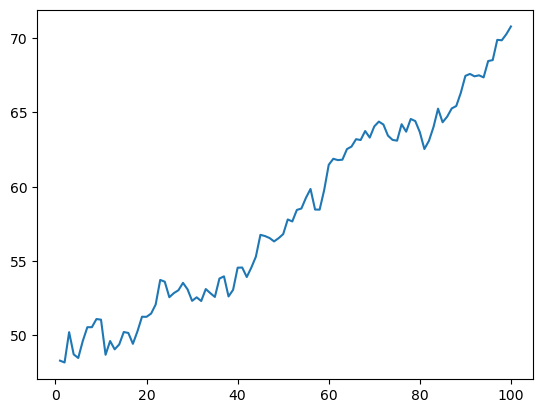

In [54]:

plt.plot(day_new, scaler.inverse_transform(df1[1158:1158+len(day_new)]))
plt.plot(day_pred, scaler.inverse_transform(lst_output))

plt.show()